# TASK 3: Data Visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/princ/Documents/project/outputs/Companies.csv")
df.head()

,Rank,Name,Industry,Revenue (USD billions),Employees,Headquarters
0,1,Walmart,Retail,"6,80,985",5.10%,"21,00,000"
1,2,Amazon,Retail and cloud computing,"6,37,959",11.00%,"15,56,000"
2,3,UnitedHealth Group,Healthcare,"4,00,278",7.70%,"4,00,000"
3,4,Apple,Technology,"3,91,035",2.00%,"1,64,000"
4,5,CVS Health,Healthcare,"3,72,809",4.20%,"2,59,500"


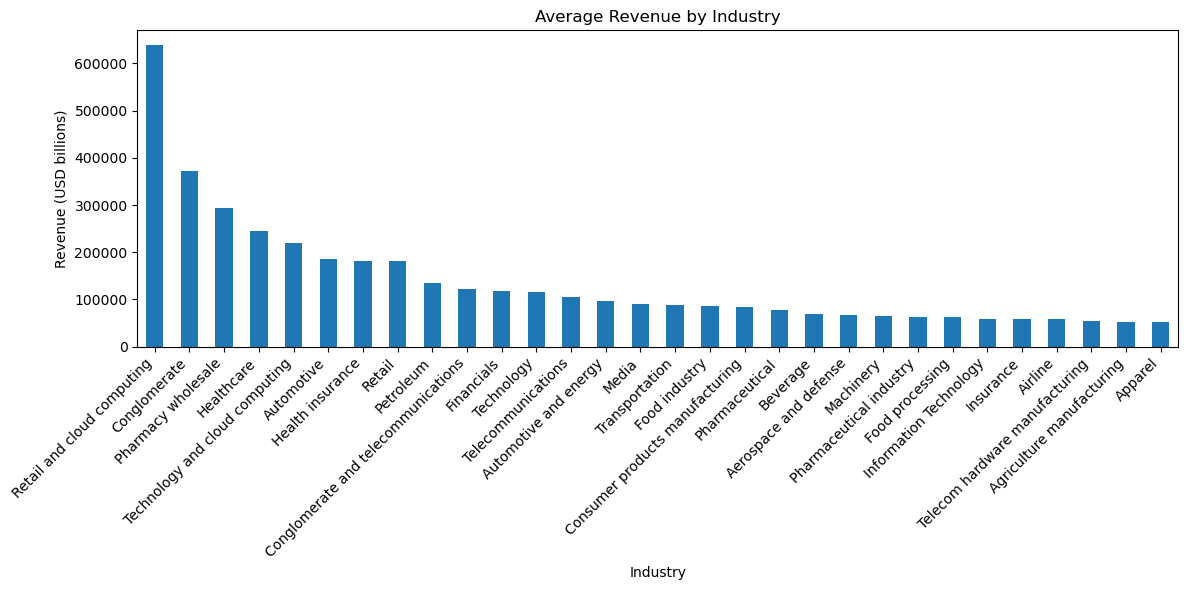

In [6]:
# Revenue by Industry

import pandas as pd
import matplotlib.pyplot as plt

# Convert Revenue column to numeric
df['Revenue (USD billions)'] = pd.to_numeric(
    df['Revenue (USD billions)'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# Calculate average revenue by industry
industry_revenue = (
    df.groupby('Industry')['Revenue (USD billions)']
      .mean()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
industry_revenue.plot(kind='bar')
plt.title("Average Revenue by Industry")
plt.xlabel("Industry")
plt.ylabel("Revenue (USD billions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
print(df[['Industry', 'Revenue (USD billions)']].head())

                     Industry  Revenue (USD billions)
0                      Retail                  680985
1  Retail and cloud computing                  637959
2                  Healthcare                  400278
3                  Technology                  391035
4                  Healthcare                  372809


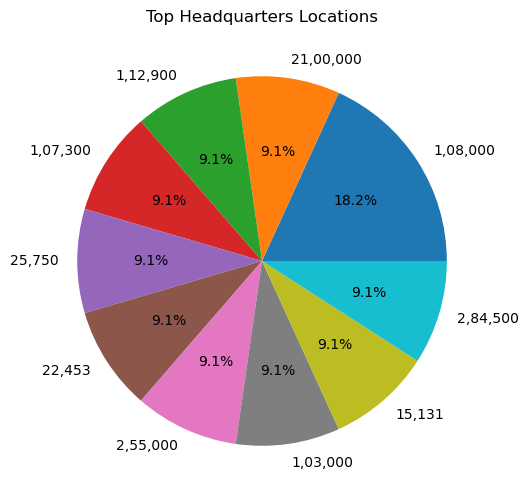

In [9]:
# 2. Headquarters Distribution
# Count the occurrences of each headquarters location
top_hq = df['Headquarters'].value_counts().head(10)

# Create a figure with a specified size
plt.figure(figsize=(10, 6))

# Plot the top 10 headquarters locations as a pie chart
top_hq.plot(
    kind='pie',          # Pie chart
    autopct='%1.1f%%'    # Display percentage values on slices
)

# Add a title to the chart
plt.title("Top Headquarters Locations")

# Remove the default y-axis label
plt.ylabel("")

# Display the chart
plt.show()

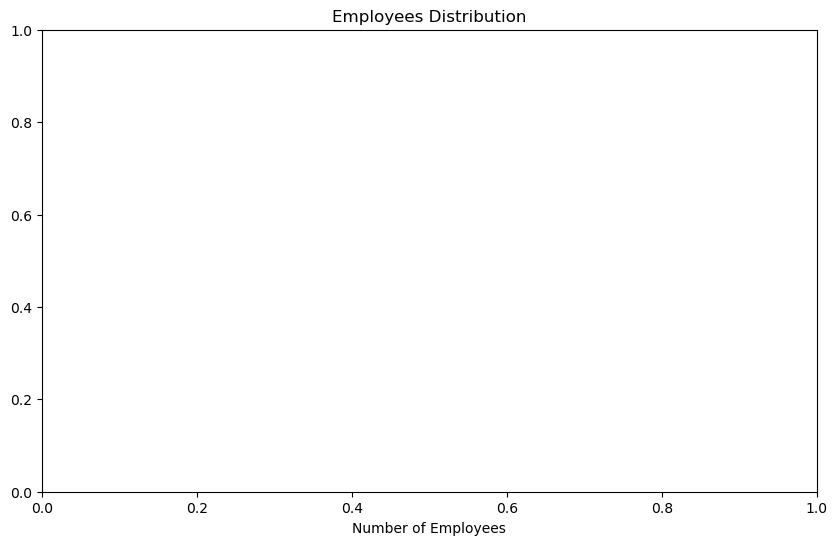

In [19]:
# 3. Employees Distribution
# Clean Employees column
df['Employees'] = (
    df['Employees']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['Employees'] = pd.to_numeric(df['Employees'], errors='coerce')

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Employees'].dropna())
plt.title("Employees Distribution")
plt.xlabel("Number of Employees")
plt.show()

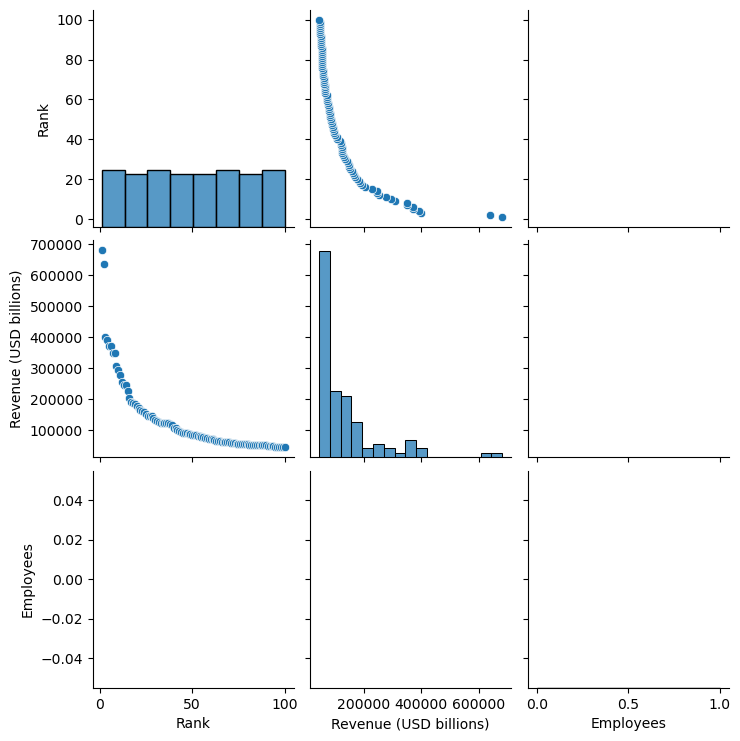

In [23]:
# 4. Pairplot Visualization
mdf = df.select_dtypes(include=['number'])
sns.pairplot(mdf)
plt.show()

# pair plot shows
1.Relationships between numerical variables
2.Distribution patterns
Correlation insights

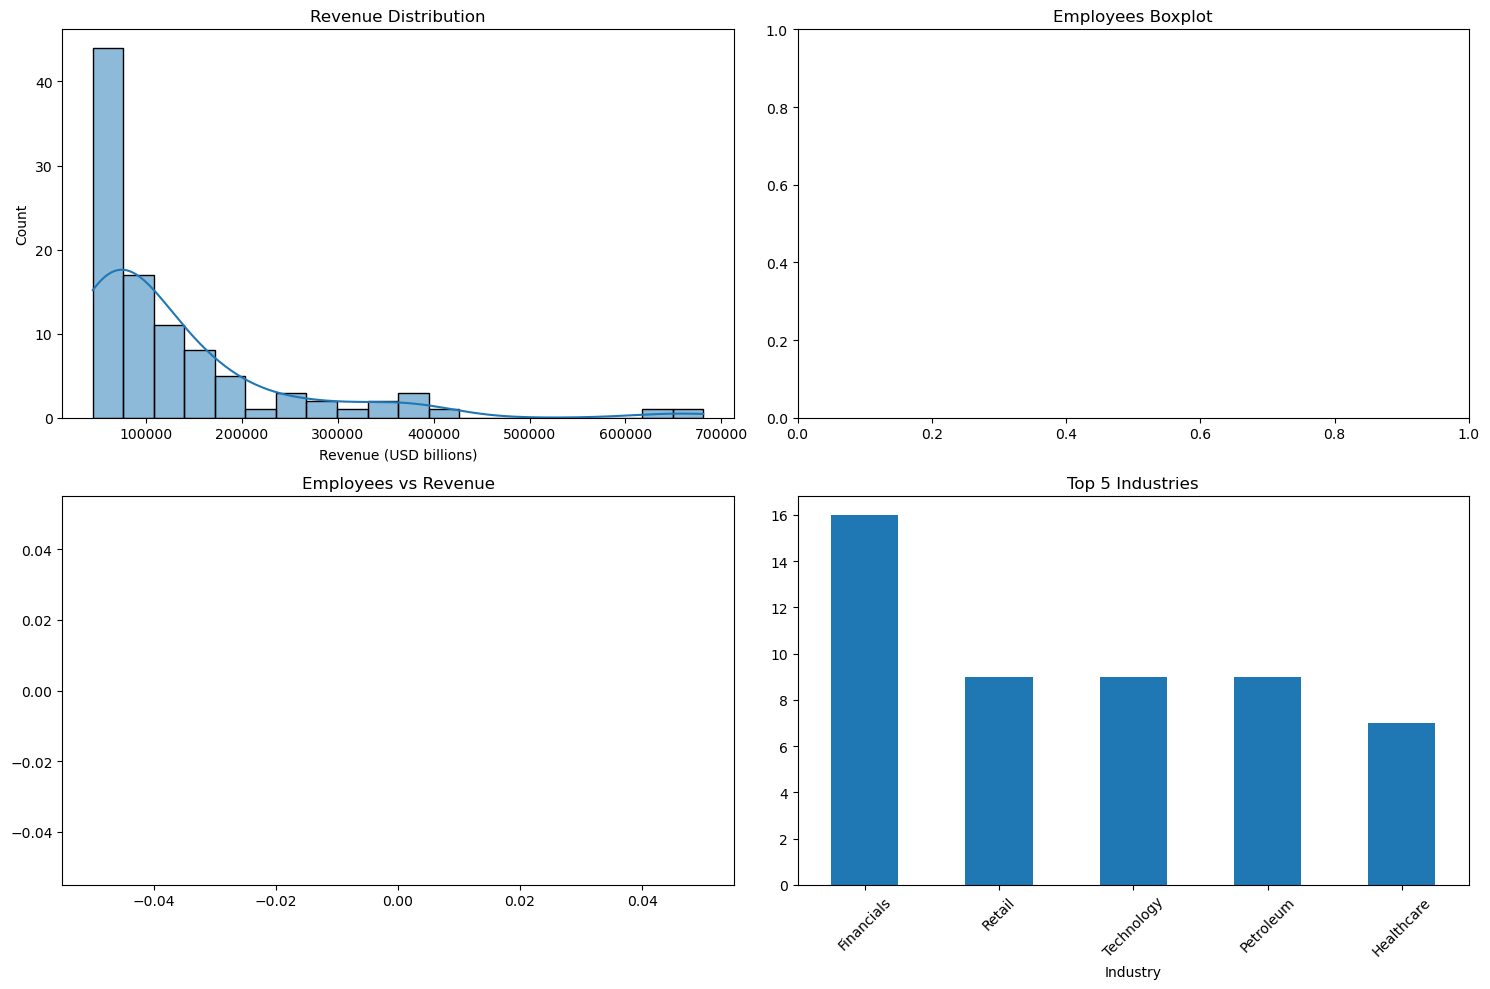

In [29]:
# 5. Professional Dashboard-style Visualization
# Clean Employees column
df['Employees'] = (
    df['Employees']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['Employees'] = pd.to_numeric(df['Employees'], errors='coerce')

# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Revenue Distribution
sns.histplot(df['Revenue (USD billions)'].dropna(), bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Revenue Distribution")

# Employees Boxplot
sns.boxplot(x=df['Employees'].dropna(), ax=axes[0, 1])
axes[0, 1].set_title("Employees Boxplot")

# Employees vs Revenue
sns.scatterplot(
    x='Employees',
    y='Revenue (USD billions)',
    data=df,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Employees vs Revenue")

# Top Industries
df['Industry'].value_counts().head(5).plot(
    kind='bar',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Top 5 Industries")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()